# Imports

In [56]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# EDA

In [57]:
df = pd.read_csv('ObesityDataSet_raw_and_data_sinthetic.csv')
df.head(5)

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


In [58]:
print(df.shape)

(2111, 17)


In [59]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Gender                          2111 non-null   str    
 1   Age                             2111 non-null   int64  
 2   Height                          2111 non-null   float64
 3   Weight                          2111 non-null   float64
 4   family_history_with_overweight  2111 non-null   str    
 5   FAVC                            2111 non-null   str    
 6   FCVC                            2111 non-null   float64
 7   NCP                             2111 non-null   float64
 8   CAEC                            2111 non-null   str    
 9   SMOKE                           2111 non-null   str    
 10  CH2O                            2111 non-null   float64
 11  SCC                             2111 non-null   str    
 12  FAF                             2111 non-null

In [60]:
print(df.isnull().sum())

Gender                            0
Age                               0
Height                            0
Weight                            0
family_history_with_overweight    0
FAVC                              0
FCVC                              0
NCP                               0
CAEC                              0
SMOKE                             0
CH2O                              0
SCC                               0
FAF                               0
TUE                               0
CALC                              0
MTRANS                            0
NObeyesdad                        0
dtype: int64


Now we can see that the data checks for overwight as `NObeyesdad` is the target let's visualize it for more understanding

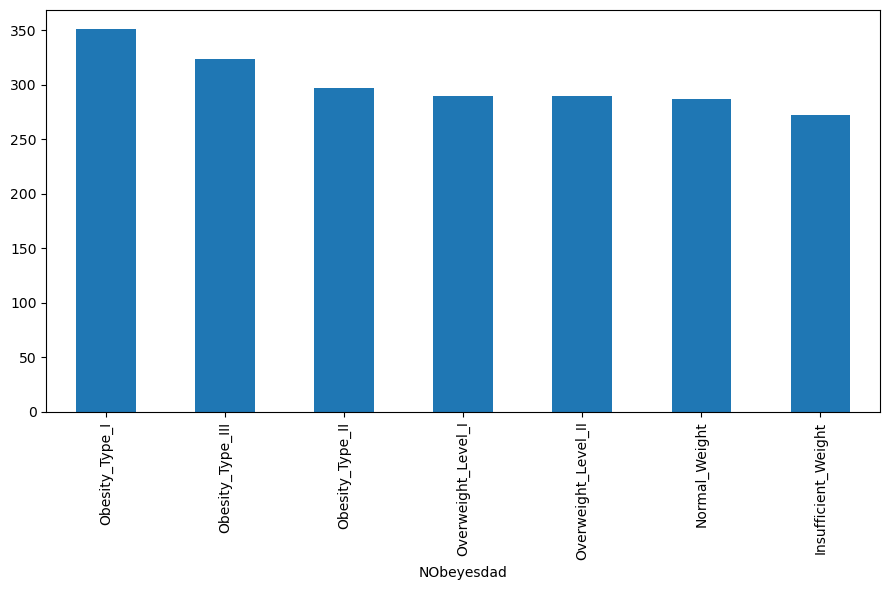

In [61]:
plt.figure(figsize=(9,6))
df['NObeyesdad'].value_counts().plot(kind='bar')
plt.tight_layout()
plt.show()

# Preprocessing 

In [62]:
# Separete the features and target 

X = df.drop('NObeyesdad',axis=1)
y =  df['NObeyesdad']

# Encode the target 
label_enc = LabelEncoder()
y_enc = label_enc.fit_transform(y)

# Encode categorial features with one hot encoder
X_enc = pd.get_dummies(X,drop_first=True)
print(X_enc.shape)
X_enc.head()

(2111, 23)


,Age,Height,Weight,FCVC,NCP,CH2O,FAF,TUE,Gender_Male,family_history_with_overweight_yes,...,CAEC_no,SMOKE_yes,SCC_yes,CALC_Frequently,CALC_Sometimes,CALC_no,MTRANS_Bike,MTRANS_Motorbike,MTRANS_Public_Transportation,MTRANS_Walking
0,21,1.62,64.0,2.0,3.0,2.0,0.0,1.0,False,True,...,False,False,False,False,False,True,False,False,True,False
1,21,1.52,56.0,3.0,3.0,3.0,3.0,0.0,False,True,...,False,True,True,False,True,False,False,False,True,False
2,23,1.80,77.0,2.0,3.0,2.0,2.0,1.0,True,True,...,False,False,False,True,False,False,False,False,True,False
3,27,1.80,87.0,3.0,3.0,2.0,2.0,0.0,True,False,...,False,False,False,True,False,False,False,False,False,True
4,22,1.78,89.8,2.0,1.0,2.0,0.0,0.0,True,False,...,False,False,False,False,True,False,False,False,True,False


# Split & Scale

In [63]:
scaler = StandardScaler()
X_train_sc= scaler.fit_transform(X_enc)

X_train, X_test, y_train, y_test = train_test_split(X_train_sc, y_enc, test_size=0.2, random_state=42)

print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)

Training shape: (1688, 23)
Testing shape: (423, 23)


# Training the model

The test accuracy is 0.8676122931442081


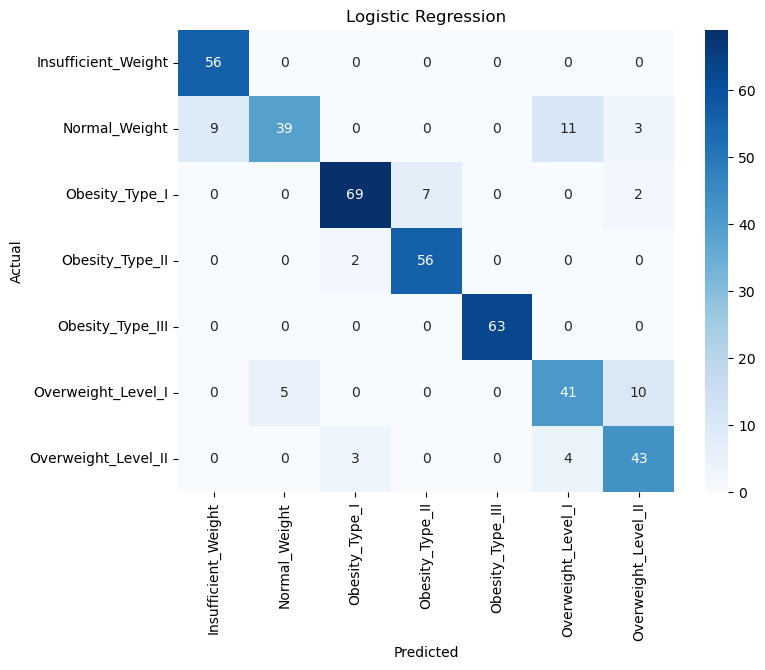

In [64]:
log_model = LogisticRegression(random_state=42)
log_model.fit(X_train,y_train)

y_pred_log = log_model.predict(X_test)

#Evaluation 
test_accuracy = accuracy_score(y_test, y_pred_log)
print('The test accuracy is', test_accuracy)

#Confusion MATRIX
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, y_pred_log), annot=True, fmt='d', cmap='Blues', xticklabels=label_enc.classes_, yticklabels=label_enc.classes_)
plt.title('Logistic Regression')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

The test accuracy is 0.9290780141843972


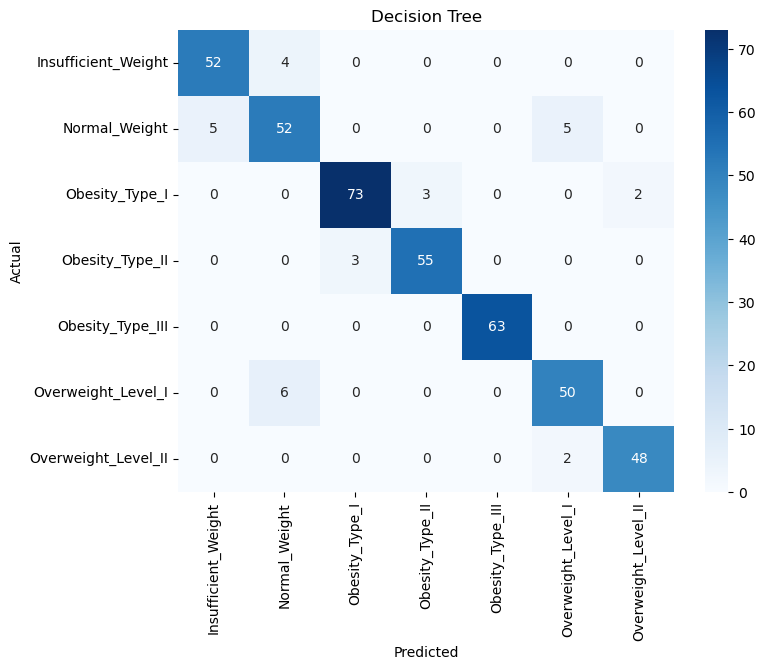

In [65]:
tree_model = DecisionTreeClassifier(random_state=42)
tree_model.fit(X_train,y_train)

y_pred_tree = tree_model.predict(X_test)

#Evaluation 
test_accuracy = accuracy_score(y_test, y_pred_tree)
print('The test accuracy is', test_accuracy)

#Confusion MATRIX
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, y_pred_tree), annot=True, fmt='d', cmap='Blues', xticklabels=label_enc.classes_, yticklabels=label_enc.classes_)
plt.title('Decision Tree')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()